# 03 — Segmentation Analysis (heterogeneous treatment effects)
Does the ad work equally for everyone? Same z-test, run within exposure
terciles and by most-ads day. This is what turns "is there an effect" into
"what should we actually do".

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

res = json.loads(open("../report/results.json").read())
exp = pd.DataFrame(res["by_exposure"])
exp[["segment", "n_ad", "n_psa"]].join(
    exp[["rate_a", "rate_b", "rel_lift", "p_value"]].apply(
        lambda c: c.map(lambda v: f"{v:.4f}")))

,segment,n_ad,n_psa,rate_a,rate_b,rel_lift,p_value
0,Low (1-10),249499,11276,0.0033,0.0040,-0.1835,0.1841
1,Medium (11-50),248875,9385,0.0189,0.0158,0.1965,0.0298
2,High (50+),66203,2863,0.1346,0.0793,0.6982,0.0000


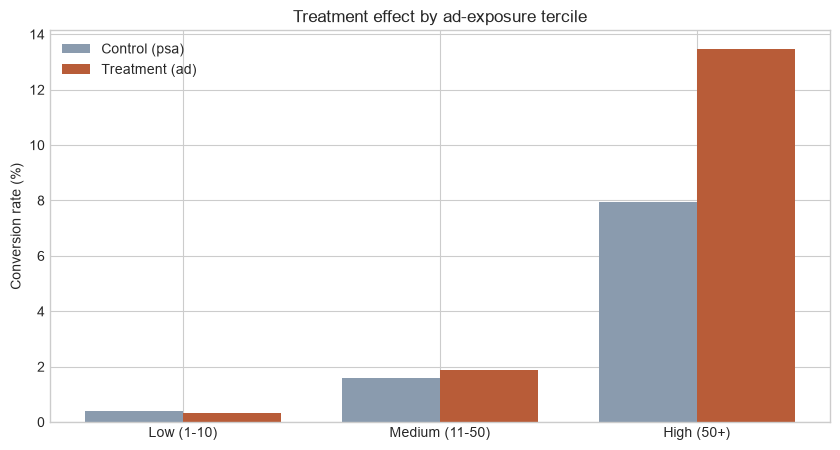

In [2]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = range(len(exp))
w = 0.38
ax.bar([i - w/2 for i in x], exp["rate_b"] * 100, w, label="Control (psa)", color="#8A9BAE")
ax.bar([i + w/2 for i in x], exp["rate_a"] * 100, w, label="Treatment (ad)", color="#B85C38")
ax.set_xticks(list(x), exp["segment"])
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Treatment effect by ad-exposure tercile")
ax.legend()
fig.tight_layout(); fig.savefig("figures/effect_by_exposure.png", dpi=150)
plt.show()

In [3]:
days = pd.DataFrame(res["by_day"]).sort_values("rel_lift", ascending=False)
print(days[["segment", "rate_a", "rate_b", "rel_lift", "p_value"]]
      .round(4).to_string(index=False))

  segment  rate_a  rate_b  rel_lift  p_value
  Tuesday  0.0304  0.0144    1.1069   0.0000
Wednesday  0.0254  0.0158    0.6089   0.0004
 Saturday  0.0213  0.0140    0.5224   0.0075
   Monday  0.0332  0.0226    0.4736   0.0005
   Friday  0.0225  0.0163    0.3780   0.0116
   Sunday  0.0246  0.0206    0.1954   0.1572
 Thursday  0.0216  0.0202    0.0695   0.5548


**Caveat — multiple comparisons:** slicing by segment multiplies the chance
of a spurious "significant" cell; segment findings here are treated as
directional evidence for targeting, not as independent confirmatory tests
(a Bonferroni-adjusted alpha of 0.05/10 = 0.005 would be the strict bar).